In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette="colorblind")

# Ex 5.1

In the US macroeconomic dataset, check if the inflation rate (`infl`) is stationary. If it is not, ensure its stationarity using an sktime transformer. Plot both the levels and the differenced series.

Write your code instead of "???".

In [3]:
!pip install sktime
from sktime.datasets.forecasting import Macroeconomic

df = Macroeconomic().load()[1]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.8 MB/s eta 0:00:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 203 entries, 1959Q1 to 2009Q3
Freq: Q-DEC
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   realgdp   203 non-null    float64
 1   realcons  203 non-null    float64
 2   realinv   203 non-null    float64
 3   realgovt  203 non-null    float64
 4   realdpi   203 non-null    float64
 5   cpi       203 non-null    float64
 6   m1        203 non-null    float64
 7   tbilrate  203 non-null    float64
 8   unemp     203 non-null    float64
 9   pop       203 non-null    float64
 10  infl      203 non-null    float64
 11  realint   203 non-null    float64
dtypes: float64(12)
memory usage: 20.6 KB


In [6]:
# check for stationarity
from statsmodels.tsa.stattools import adfuller

adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(df["infl"], regression="n")
print(f"p-value: {pval:.3f}")

p-value: 0.085


In [7]:
# perform transformation
from sktime.transformations.series.difference import Differencer

transformer = Differencer(lags=[1])
transformer.fit(df["infl"])
df["infl_diff"] = transformer.transform(df["infl"])

df[["infl", "infl_diff"]].head()

,infl,infl_diff
Period,,
1959Q1,0.00,0.00
1959Q2,2.34,2.34
1959Q3,2.74,0.40
1959Q4,0.27,-2.47
1960Q1,2.31,2.04


<Axes: xlabel='Period'>

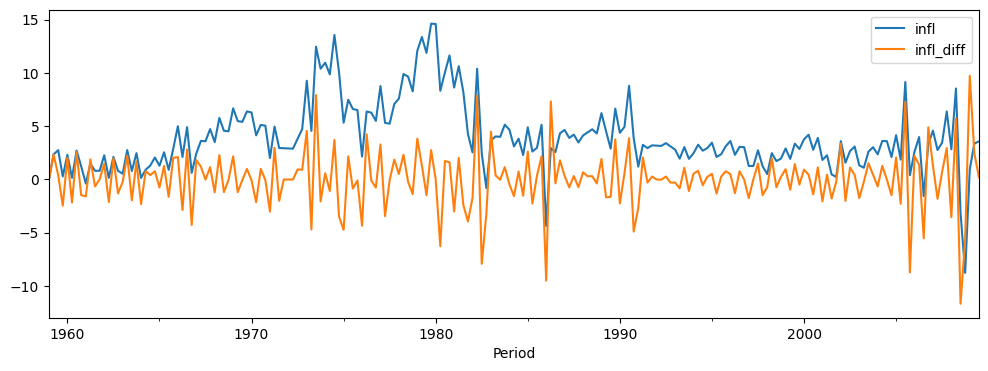

In [10]:
# plot the original and transformed series
df[["infl", "infl_diff"]].plot(figsize=(12,4))

In [11]:
# ensure the transformed series is stationary
adf_stat, pval, lags, obs, crit_vals, icbest = adfuller(df["infl_diff"], regression="n")
print(f"P-value: {pval:.3f}")

P-value: 0.000


<Axes: xlabel='Period'>

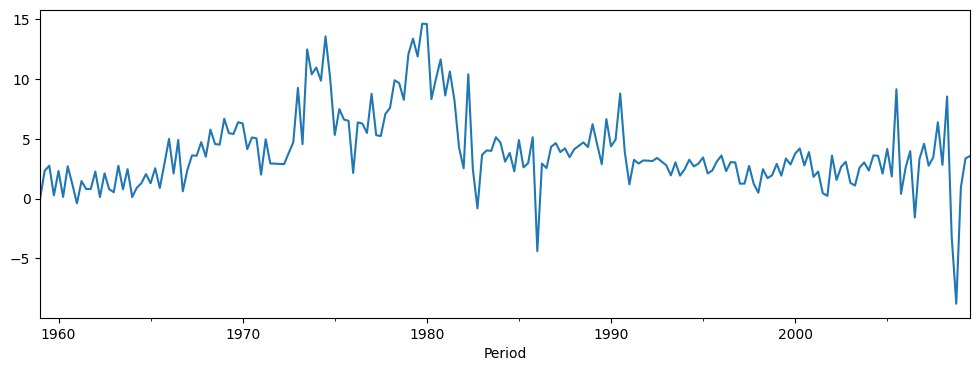

In [12]:
# inverse-transform
df["infl_diff_invtransform"] = transformer.inverse_transform(df["infl_diff"])
df["infl_diff_invtransform"].plot(figsize=(12,4))

# Ex. 5.2

The global economy data file contains various economic variables on most countries in the world since 1960. Save the data file locally (see the link below). Select all economic variables available on United Kingdom. For each economic variable, check if it is normally distributed, and if it is not, apply Box-Cox transformation and see if it creates a normally distributed series. Print the optimal lambda for each variable.

Data file: https://otexts.com/fpppy/data/global_economy.csv

In [ ]:
# load the data and use the "ds" column as the time index
df = pd.read_csv("global_economy.csv", parse_dates=["ds"], index_col="ds")

# forward and backward fill missing values
df = df.ffill().bfill()

df.info()

In [ ]:
# select data on the United Kingdom and delete identifier columns
df = df[???].drop(columns=["unique_id", "Code"])

In [ ]:
from sktime.transformations.series.boxcox import BoxCoxTransformer
from scipy.stats import shapiro

# check for normality each variable and perform Box-Cox transformation if necessary
???

# Ex 5.3

A series is called "trend-stationary" if, after removing the trend, it becomes stationary. In the US Macroeconomic dataset, check which variables contain a trend using Mann-Kendall test. For those series, where trend is present, estimate the trend using a regression and subtract it from the original series. Use sktime's transformers to perform the transformations. Check if the series has become stationary after de-trending.

In [ ]:
import pymannkendall as mk

from sktime.datasets.forecasting import Macroeconomic
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster


df = Macroeconomic().load()[1]

for c in df.columns:

    mktest = mk.yue_wang_modification_test(df[c], lag=4)

    ???

# Ex. 5.4

The data contains simulated daily sales of three items. Examine the series for "item_3". De-seasonalise and de-trend the series using STL. Check if the residuals are stationary.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/simulated_items_sales.csv",
                  parse_dates=["date"], index_col="date")
df.info()

In [ ]:
# create a plot to check for annual patterns
???

In [ ]:
# create a plot to check for monthly and weekly patterns
df[???]["item_3"].plot(figsize=(12,4))

In [ ]:
# applyseasonal transformation

from sktime.transformations.series.detrend import STLTransformer

stl = STLTransformer(sp=???, seasonal=5, trend=367, return_components=True)
components = stl.fit_transform(???)

# plot the transformed series

???

In [ ]:
# check if the series is stationary after removing trend and seasonality
???

# Ex 5.5

The file "eth-btc-usd-2018-2026.csv" contains the price of Bitcoin between 01/01/2018 and 31/12/2025. Ensure the column containing date and time information is used as the index. Is the series stationary? If not, stationarise it using an sktime transformer. Then use the IQR method to perform outlier detection and create a plot indicating outliers.

In [ ]:
df = pd.read_csv("eth-btc-usd-2018-2026.csv", parse_dates=[???], index_col=???)
df.info()

In [ ]:
# check stationarity visually
???

In [ ]:
# ADF test for stationarity
???

In [ ]:
# perform transformation
???

# check for stationarity
???

In [ ]:
# plot the transformed series
???

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.utils.validation import validate_data


class UnivariateOutlierDetector(TransformerMixin, BaseEstimator):

    def __init__(self, factor=1.5, method="iqr"):
        """Detect outliers in a univariate series using either the
        IQR or the standard deviation method.
        Parameters
        ----------
        factor : float, default=1.5
            The factor to multiply the IQR or the standard deviation
            by to determine the outlier thresholds
        method : str, default="iqr"
            The method to use for outlier detection. Either "iqr" or
            "std"
        """
        self.factor = factor
        self.method = method

    def fit(self, X, y=None):
        self._upper, self._lower = None, None
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X)
        try:
            assert X.isnull().sum().sum() == 0
        except AttributeError:
            assert np.isnan(X).sum() == 0
        if self.method == "iqr":
            q25 = np.percentile(X, 25, axis=0)
            q75 = np.percentile(X, 75, axis=0)
            cut_off = (q75 - q25) * self.factor
            self._lower = q25 - cut_off
            self._upper = q75 + cut_off
        elif self.method == "std":
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            self._lower = mean - self.factor * std
            self._upper = mean + self.factor * std
        self._is_fitted = True
        return self

    def predict(self, X, y=None):
        """Return True to indicate outliers, False to indicate inliers
        """
        check_is_fitted(self)
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X, reset=False)
        return np.where(((X >= self._lower) & (X <= self._upper)), False, True)

    def transform(self, X, y=None):
        """Detect outliers and set them to np.nan
        """
        check_is_fitted(self)
        if type(X) == pd.Series:
            X = X.values.reshape(-1, 1)
        X = validate_data(self, X, reset=False)
        X = X.copy().astype('float')
        yhat = self.predict(X)
        X[yhat] = np.nan
        return X

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted

In [ ]:
# instantiate a transformer
???
iqr_transformer.fit(df["BTC-USD_diff"])
yhat = iqr_transformer.predict(df["BTC-USD_diff"])

In [ ]:
# create a plot showing outliers
???

# Ex 5.6

Put the differencer and the outlier detector from the previous exercise into a pipeline. Include into the pipeline also a suitable imputer. Call the `fit_transform` method of the pipeline on the BTC-USD series. Plot the output and compare with the plot produced at end of the previous exercise.

In [ ]:
from sktime.transformations.series.impute import Imputer
from sktime.transformations.compose import TransformerPipeline

???

In [ ]:
# plot the transformed series
???

# Citing this notebook
If you use this notebook in your work, please cite it as follows:

Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf